---
tags: [algorithm, primitive, resource-estimation]
---

# Introduction to Quantum Fourier transform (QFT)

量子フーリエ変換（QFT）は、離散フーリエ変換の量子版です。量子位相推定、位数発見、計算基底での表現と位相での表現を行き来する多くのアルゴリズムで、中核的なサブルーチンとして使われます。

このページでは、古典のフーリエ変換の見方から始め、QFT回路を概観し、[WikipediaのQFTの例](https://en.wikipedia.org/wiki/Quantum_Fourier_transform#Example)と、NielsenとChuangの*Quantum Computation and Quantum Information*{cite:p}`10.1017/CBO9780511976667`で示される標準的な3量子ビットの$F_8$例をQamomileで実装します。最後まで進むと、QFT回路を描画し、ローカルのQiskitシミュレータで実行し、標準分解のリソース推定を確認するQamomileの量子カーネルを作成できます。

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

In [2]:
from itertools import product

import numpy as np

import qamomile.circuit as qmc
from qamomile.circuit.stdlib.qft import qft
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## フーリエ変換

フーリエ変換は、データを周波数の成分として書き直します。連続的な設定では、入力は時間や空間上の関数であり、出力は各周波数がどれだけ含まれているかを表します。有限の計算でよく使うのが**離散フーリエ変換**（Discrete Fourier Transform、DFT）です。

ベクトル$x = (x_0, x_1, \ldots, x_{N-1})$に対して、QFTで使うユニタリ正規化されたDFTの規約は次のように書けます。

$$
y_k = \frac{1}{\sqrt{N}}\sum_{j=0}^{N-1} x_j e^{2\pi i jk / N},
\qquad k = 0, 1, \ldots, N-1.
$$

出力の添字$k$は周波数成分を表します。複素位相因子$e^{2\pi i jk / N}$により、各入力位置は出力周波数ごとに異なる位相で寄与します。

In [3]:
num_qubits = 3
dimension = 2**num_qubits
basis_index = 5
omega = np.exp(2j * np.pi / dimension)

signal = np.zeros(dimension, dtype=complex)
signal[basis_index] = 1.0
dft = np.fft.ifft(signal, norm="ortho")
expected_dft = np.array(
    [omega ** (basis_index * k) / np.sqrt(dimension) for k in range(dimension)]
)

print(np.round(dft, 3))
assert np.allclose(dft, expected_dft)
assert np.allclose(np.abs(dft), 1 / np.sqrt(dimension))

[ 0.354+0.j    -0.25 -0.25j   0.   +0.354j  0.25 -0.25j  -0.354+0.j
  0.25 +0.25j   0.   -0.354j -0.25 +0.25j ]


これは、添字5だけが非ゼロである基底ベクトルの古典フーリエ変換です。出力は8成分すべてで同じ大きさを持ち、位相は8乗根$\omega = e^{2\pi i/8}$の累乗で決まります。

## アルゴリズム

QFTは、同じ数学的な変換を量子振幅に適用します。$N = 2^n$のとき、計算基底状態への作用は次の通りです。

$$
\mathrm{QFT}_N \lvert x \rangle =
\frac{1}{\sqrt{N}}\sum_{k=0}^{N-1} e^{2\pi i xk/N}\lvert k \rangle.
$$

このページで使う3量子ビットの例では、$n=3$、$N=8$、$\omega = e^{2\pi i/8}$であり、次のように書けます。

$$
F_8\lvert x \rangle =
\frac{1}{\sqrt{8}}\sum_{k=0}^{7}\omega^{xk}\lvert k\rangle.
$$

古典のDFTとの重要な違いは、変換されるベクトルが量子状態ベクトルである点です。QFTの直後に測定しても、得られるのは出力確率からのサンプルだけです。位相情報は状態に残っていますが、位相推定のように後続の干渉を通じて取り出します。

標準的なQFT回路は、アダマールゲート、制御付き位相回転、最後のスワップで構成されます。$n$量子ビットのレジスタに対する厳密な分解では、密な$2^n \times 2^n$行列ではなく、$O(n^2)$個の2量子ビット回転構造を使います。次の2進小数表記を使います。

$$
[0.x_jx_{j+1}\ldots x_n] =
\sum_{m=j}^{n} x_m 2^{-(m-j+1)}.
$$

### ステップ1：対象量子ビットを1つ選ぶ

レジスタを対象量子ビットごとに処理します。最後の量子ビットにアダマールゲートを適用すると、最初のフーリエ基底の因子が得られます。

$$
\lvert x_n\rangle
\xrightarrow{H}
\frac{1}{\sqrt{2}}
\left(\lvert 0\rangle + e^{2\pi i[0.x_n]}\lvert 1\rangle\right).
$$

### ステップ2：制御付き位相回転を加える

手前の量子ビットからの制御付き位相回転により、2進小数に残りのビットが加わります。対象量子ビット$x_j$に対して、アダマールゲートと制御付き位相回転は次の状態を作ります。

$$
\lvert x_j\rangle
\longmapsto
\frac{1}{\sqrt{2}}
\left(\lvert 0\rangle + e^{2\pi i[0.x_jx_{j+1}\ldots x_n]}\lvert 1\rangle\right).
$$

回転角は、制御位置と対象位置の距離が大きくなるほど小さくなります。

$$
\theta = \frac{\pi}{2^d},
$$

ここで$d$は制御位置と対象位置の距離です。

### ステップ3：レジスタ全体で繰り返す

アダマールゲートと制御付き位相回転のパターンを繰り返すと、QFTのテンソル積表示が得られます。

$$
\mathrm{QFT}\lvert x_1x_2\ldots x_n\rangle =
\frac{1}{\sqrt{2^n}}
\bigotimes_{j=n}^{1}
\left(\lvert 0\rangle + e^{2\pi i[0.x_jx_{j+1}\ldots x_n]}\lvert 1\rangle\right).
$$

3量子ビットの場合は次のようになります。

$$
\mathrm{QFT}\lvert x_1x_2x_3\rangle =
\frac{1}{\sqrt{8}}
\left(\lvert 0\rangle + e^{2\pi i[0.x_3]}\lvert 1\rangle\right)
\otimes
\left(\lvert 0\rangle + e^{2\pi i[0.x_2x_3]}\lvert 1\rangle\right)
\otimes
\left(\lvert 0\rangle + e^{2\pi i[0.x_1x_2x_3]}\lvert 1\rangle\right).
$$

### ステップ4：出力順序を反転する

教科書的なQFT分解は、自然には量子ビットを逆順に出力します。最後にスワップ層を置くことで、レジスタの順序を戻します。一部のアルゴリズムではこのスワップを省き、反転した順序を古典側で追跡しますが、Qamomileの標準`qft`関数はスワップを含みます。

## Qamomileでの実装：`qft`関数

QamomileはQFTを標準ライブラリのコンポジットゲートとして提供しています。便利関数`qamomile.circuit.stdlib.qft.qft`は`Vector[Qubit]`を受け取り、レジスタ全体にQFTを適用して、変換後のベクトルを返します。

ここでは、添字5に対応する3量子ビット基底状態$\lvert 101\rangle$を準備してQFTを適用します。これは上の例の$F_8\lvert 5\rangle$に対応します。各出力振幅の大きさは$1/\sqrt{8}$なので、直接測定すると8通りの基底状態が一様にサンプリングされます。

In [4]:
@qmc.qkernel
def qft_on_five() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(3, name="q")
    q[0] = qmc.x(q[0])
    q[2] = qmc.x(q[2])
    q = qft(q)
    return qmc.measure(q)

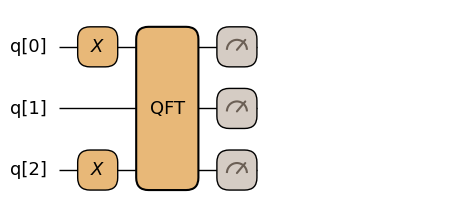

In [5]:
qft_on_five.draw()

コンパクトな図では、QFTを1つのコンポジット演算として表示します。バックエンドが受け取る回路を見たい場合は、トランスパイルします。ここでは、Qiskitはネイティブの`QFTGate`を出力し、その後に測定が続きます。

In [6]:
qiskit_circuit = transpiler.to_circuit(qft_on_five)
print(qiskit_circuit.draw())

     ┌───┐┌──────┐┌─┐      
q_0: ┤ X ├┤0     ├┤M├──────
     └───┘│      │└╥┘┌─┐   
q_1: ─────┤1 Qft ├─╫─┤M├───
     ┌───┐│      │ ║ └╥┘┌─┐
q_2: ┤ X ├┤2     ├─╫──╫─┤M├
     └───┘└──────┘ ║  ║ └╥┘
c: 3/══════════════╩══╩══╩═
                   0  1  2 


次に、量子カーネルをローカルで実行します。量子状態をサンプリングするため結果は確率的ですが、3ビットの各結果の期待確率は$1/8$です。

In [7]:
try:
    from qiskit_aer import AerSimulator

    backend = AerSimulator(seed_simulator=1234, max_parallel_threads=1)
except ImportError:
    from qiskit.providers.basic_provider import BasicSimulator

    backend = BasicSimulator()
    backend.set_options(seed_simulator=1234)

shots = 512
result = (
    transpiler.transpile(qft_on_five)
    .sample(transpiler.executor(backend), shots=shots)
    .result()
)
counts = dict(result.results)
expected_outcomes = set(product([0, 1], repeat=3))

for outcome in sorted(expected_outcomes):
    probability = counts.get(outcome, 0) / shots
    print(f"{outcome}: {probability:.3f}")

assert result.shots == shots
assert sum(counts.values()) == shots
assert set(counts).issubset(expected_outcomes)
assert all(isinstance(outcome, tuple) and len(outcome) == 3 for outcome in counts)

(0, 0, 0): 0.158
(0, 0, 1): 0.107
(0, 1, 0): 0.119
(0, 1, 1): 0.113
(1, 0, 0): 0.121
(1, 0, 1): 0.131
(1, 1, 0): 0.115
(1, 1, 1): 0.135


最後に、Qamomileでリソースを推定します。この量子カーネルでは、標準的な3量子ビットQFTが3個のアダマールゲート、3個の制御付き位相回転、1個のスワップを使います。追加の2個のXゲートは$\lvert 101\rangle$の準備に使います。

In [8]:
estimate = qft_on_five.estimate_resources().simplify()
print("量子ビット数:", estimate.qubits)
print("総ゲート数:", estimate.gates.total)
print("単一量子ビットゲート数:", estimate.gates.single_qubit)
print("2量子ビットゲート数:", estimate.gates.two_qubit)
print("回転ゲート数:", estimate.gates.rotation_gates)
print("クリフォードゲート数:", estimate.gates.clifford_gates)

assert estimate.qubits == 3
assert estimate.gates.total == 9
assert estimate.gates.single_qubit == 5
assert estimate.gates.two_qubit == 4
assert estimate.gates.rotation_gates == 3
assert estimate.gates.clifford_gates == 6

量子ビット数: 3
総ゲート数: 9
単一量子ビットゲート数: 5
2量子ビットゲート数: 4
回転ゲート数: 3
クリフォードゲート数: 6


## まとめ

- DFTは有限ベクトルを周波数成分に書き換えます。QFTは同じ変換を量子振幅に適用します。
- 3量子ビットの$F_8$例では、$\lvert 5\rangle = \lvert 101\rangle$を、8通りすべての計算基底状態にわたる等振幅の位相パターンへ写します。
- Qamomileでは、`qamomile.circuit.stdlib.qft.qft`で`Vector[Qubit]`に直接QFTを適用できます。
- `draw()`、バックエンド実行、`estimate_resources()`により、同じ量子カーネルの回路表示、サンプルされた挙動、ゲートコストを確認できます。